End to End Implementation fo Alex Net Arch from dataset to model Arch to Training to Evaluation

### Set Up

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import keras
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [3]:
cuda_is = torch.cuda.is_available()
print(cuda_is)

True


### The Dataset

> Info : ImageNet dataset of over 15 million labeled high- resolution
images belonging to roughly 22,000 categories.

> Paper : ILSVRC uses a subset of ImageNet with roughly 1000 images in each of 1000 categories.
In all, there are roughly 1.2 million training images, 50,000 validation images, and 150,000 testing images.
Paper uses all these images

> Me : We use 50000 labeled high-resolution imaged of ImageNet validation dataset

> Paper : Down-sampled the images to a fixed resolution of 256 × 256. Given a rectangular image, we first rescaled the image such that the shorter side was of length 256, and then cropped out the central 256 × 256 patch from the resulting image. Then subtracting the mean activity over the training set from each pixel.

> Me : Implemented this data preprocessing as utils



In [4]:
dir = "ILSVRC2010_images"
print(f"Validation images: {len(os.listdir(os.path.join(dir, 'val')))}")

Validation images: 50000


In [5]:
# preprocess utils
IMAGENET_MEAN = tf.constant([123.68, 116.779, 103.939], dtype=tf.float32) # Fixed commonly used mean, paper computed it for their e dataset might be different, dint publish those.

def resize_shorter_side(image):
    return tf.image.resize(image, size=(256, 256), preserve_aspect_ratio=True, antialias=True)

def center_crop(image):
    return tf.image.resize_with_crop_or_pad(image, target_height=256, target_width=256)

def subtract_mean(image):
    return tf.cast(image, tf.float32) - IMAGENET_MEAN

def preprocess(image):
    image = resize_shorter_side(image)
    image = center_crop(image)
    image = subtract_mean(image)
    return image

In [6]:
label_path = os.path.join(dir, "ILSVRC2010_validation_ground_truth.txt")
df = pd.read_csv(label_path, header=None)
df.columns = pd.Index(["class"])
df["id"] = df.index+1
df["id"] = df["id"].astype(str).str.zfill(5)
df['class'] = df['class'].astype(str)
df

,class,id
0,78,00001
1,854,00002
2,435,00003
3,541,00004
4,973,00005
...,...,...
49995,467,49996
49996,646,49997
49997,68,49998
49998,93,49999


In [7]:
prefix = "ILSVRC2010_val_000"
df['id'] = prefix+df['id'].astype(str) + '.JPEG'
datagen = ImageDataGenerator()

In [8]:
datagen = ImageDataGenerator(preprocessing_function=preprocess)
data = datagen.flow_from_dataframe(dataframe=df, directory=os.path.join(dir, 'val'), x_col="id",
                                   y_col="class", batch_size=32, target_size=(256, 256),class_mode="categorical")

Found 50000 validated image filenames belonging to 1000 classes.


In [9]:
images, labels = next(data)

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Class indices mapping:", data.class_indices)

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32, 1000)
Class indices mapping: {'1': 0, '10': 1, '100': 2, '1000': 3, '101': 4, '102': 5, '103': 6, '104': 7, '105': 8, '106': 9, '107': 10, '108': 11, '109': 12, '11': 13, '110': 14, '111': 15, '112': 16, '113': 17, '114': 18, '115': 19, '116': 20, '117': 21, '118': 22, '119': 23, '12': 24, '120': 25, '121': 26, '122': 27, '123': 28, '124': 29, '125': 30, '126': 31, '127': 32, '128': 33, '129': 34, '13': 35, '130': 36, '131': 37, '132': 38, '133': 39, '134': 40, '135': 41, '136': 42, '137': 43, '138': 44, '139': 45, '14': 46, '140': 47, '141': 48, '142': 49, '143': 50, '144': 51, '145': 52, '146': 53, '147': 54, '148': 55, '149': 56, '15': 57, '150': 58, '151': 59, '152': 60, '153': 61, '154': 62, '155': 63, '156': 64, '157': 65, '158': 66, '159': 67, '16': 68, '160': 69, '161': 70, '162': 71, '163': 72, '164': 73, '165': 74, '166': 75, '167': 76, '168': 77, '169': 78, '17': 79, '170': 80, '171': 81, '172': 82, '173': 83, '1

In [10]:
labels[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [11]:
np.argmax(labels[0])

np.int64(385)

In [12]:
images[0]

array([[[ -25.68 ,  -39.779,  -71.939],
        [ -26.68 ,  -36.779,  -69.939],
        [ -32.68 ,  -39.779,  -73.939],
        ...,
        [ -70.68 ,  -60.779,  -74.939],
        [ -82.68 ,  -73.779,  -82.939],
        [-121.68 , -113.779, -103.939]],

       [[ -28.68 ,  -42.779,  -74.939],
        [ -30.68 ,  -40.779,  -73.939],
        [ -34.68 ,  -41.779,  -75.939],
        ...,
        [ -71.68 ,  -59.779,  -76.939],
        [ -75.68 ,  -64.779,  -76.939],
        [ -84.68 ,  -73.779,  -83.939]],

       [[ -29.68 ,  -43.779,  -75.939],
        [ -31.68 ,  -41.779,  -74.939],
        [ -33.68 ,  -40.779,  -74.939],
        ...,
        [ -77.68 ,  -63.779,  -83.939],
        [ -82.68 ,  -69.779,  -84.939],
        [ -88.68 ,  -76.779,  -93.939]],

       ...,

       [[-122.68 , -116.779, -103.939],
        [-107.68 ,  -98.779,  -88.939],
        [ -97.68 ,  -85.779,  -78.939],
        ...,
        [ -97.68 ,  -84.779,  -97.939],
        [ -79.68 ,  -66.779,  -79.939],
        [

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


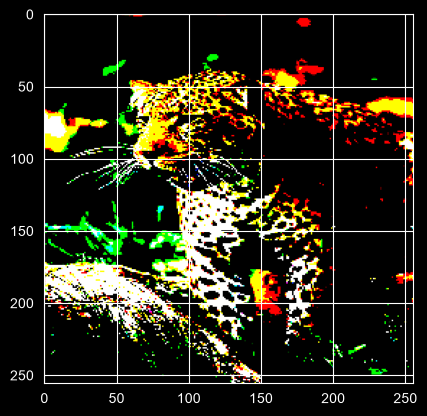

In [13]:
plt.imshow(images[0])
plt.show()

### A